# 2D linear hodograph: the feasibility *and* the transparency of a bending-magnet field

Design a 2D **bending magnet** by working in the space of the **field** (demand the mid-plane
field $B_y(x,0)=g(x)$: flat over the good-field region, rolling off over an edge width $d$)
rather than the space of position. On this **linear** ($\mu=$const, Laplace) problem two things
become legible, and it is worth keeping them strictly apart:

1. **A feasibility bound (harmonic analysis).** The gap field is the unique *harmonic* (upward)
   continuation of $g$. A $\tanh$ edge of width $d$ has its nearest complex singularity at height
   $\pi d/2$, so the demand is realizable by an iron pole at gap $h$ only if that singularity
   clears the gap:
   $$d > d^\* = \tfrac{2}{\pi}\,h \approx 0.64\,h.$$
   This is a **Cauchy–Kovalevskaya / analyticity** fact about the *demand* — **not** the
   hodograph, and **not** a "limit line" (ordinary passive saturation stays elliptic, §4).

2. **The transparency the hodograph actually buys (partial von Mises).** Keep $x$, replace $y$
   by the scalar-potential coordinate $s=-\phi$. The unknown iron-pole *shape* — a **free
   boundary** — becomes the **fixed top edge** of a rectangle in the $(x,s)$ chart, and the pole
   is read off as a coordinate line. "Design in field space" = solve for the map $y(x,s)$ on a
   fixed domain.

The compute lives in the adjacent helper
[`hodograph_feasibility_2d.py`](hodograph_feasibility_2d.py); the full 10-step visual
walk-through is in the session artifact.


In [1]:
import os, sys, json, platform, datetime
import numpy as np
sys.path.insert(0, os.getcwd())
import hodograph_feasibility_2d as hf

print(f"good-field half-width x0 = {hf.X0}, gap h = {hf.H}, feasible edge d = {hf.D}")
print(f"feasibility boundary  d* = (2/pi) h = {hf.d_star():.4f}")

good-field half-width x0 = 2.0, gap h = 1.0, feasible edge d = 0.9
feasibility boundary  d* = (2/pi) h = 0.6366


## 1. The feasibility bound $d^\*=(2/\pi)h$ is harmonic continuation, not the hodograph

A monotone-decaying edge never folds (the pole just opens up). The hard limit is the
**smoothness** of the demanded field: sharpen the edge and the *harmonic continuation* of $g$
develops a complex singularity that descends toward the mid-plane; once it enters the gap, no
single smooth iron pole can produce the field. The nearest singularity of a $\tanh$ edge sits at
$y=\pi d/2$, giving $d^\*=(2/\pi)h$. The $2/\pi$ is $\tanh$-specific; what is **universal** is the
gap scaling — *the field edge can be no sharper than $\sim$ one gap*. This is a
Cauchy–Kovalevskaya / analyticity statement about the *demand*; the hodograph plays no role in it.

In [2]:
tab = hf.feasibility_table([1.4, 1.0, 0.8, hf.d_star(), 0.5, 0.35])
print(f"{'edge d':>8}{'singularity pi*d/2':>22}{'vs gap h=1':>14}{'verdict':>14}")
for r in tab:
    print(f"{r['d']:>8.3f}{r['y_sing']:>22.3f}{'above' if r['feasible'] else 'below':>14}"
          f"{'FEASIBLE' if r['feasible'] else 'INFEASIBLE':>14}")

  edge d    singularity pi*d/2    vs gap h=1       verdict
   1.400                 2.199         above      FEASIBLE
   1.000                 1.571         above      FEASIBLE
   0.800                 1.257         above      FEASIBLE
   0.637                 1.000         below    INFEASIBLE
   0.500                 0.785         below    INFEASIBLE
   0.350                 0.550         below    INFEASIBLE


## 2. Inverse design + an independent linear-FEM verification

For a **feasible** demand ($d=0.9>d^\*$) the scalar potential has a closed form (only
$\sinh,\cosh,\sin,\cos,\operatorname{atan2}$), so the pole is read off as the equipotential
$\{\phi=\phi_0\}$. We **verify** with an independent `ngsolve` linear-FEM solve (a
manufactured-solution check on a rectangle below the singularity): impose the analytic $\phi$ on
the boundary, solve Laplace, and confirm (a) the interior $B_y(x,0)$ reproduces the demanded
$g(x)$, (b) the FEM $\phi$ equals the analytic $\phi$, (c) the FEM equipotential equals the
read-off pole.

In [3]:
res = hf.fem_verify(order=4)
print(f"feasible d={res['d']} (d*={res['d_star']:.3f}): FEASIBLE={res['feasible']}, phi0={res['phi0']:.4f}")
print(f"(a) interior B_y(x,0) vs demanded g(x)   : max rel err = {res['By_rel_err']*100:.3f} % of B0")
print(f"(b) FEM phi vs analytic phi (L2, interior): {res['phi_L2_err']:.2e}")
print(f"(c) FEM equipotential vs read-off pole    : max |dy| = {res['pole_match_err']:.2e}"
      f"  (pole gap at x=0 = {res['pole_gap_at_x0']:.3f})")

feasible d=0.9 (d*=0.637): FEASIBLE=True, phi0=-1.0151
(a) interior B_y(x,0) vs demanded g(x)   : max rel err = 0.010 % of B0
(b) FEM phi vs analytic phi (L2, interior): 1.14e-08
(c) FEM equipotential vs read-off pole    : max |dy| = 1.36e-06  (pole gap at x=0 = 1.000)


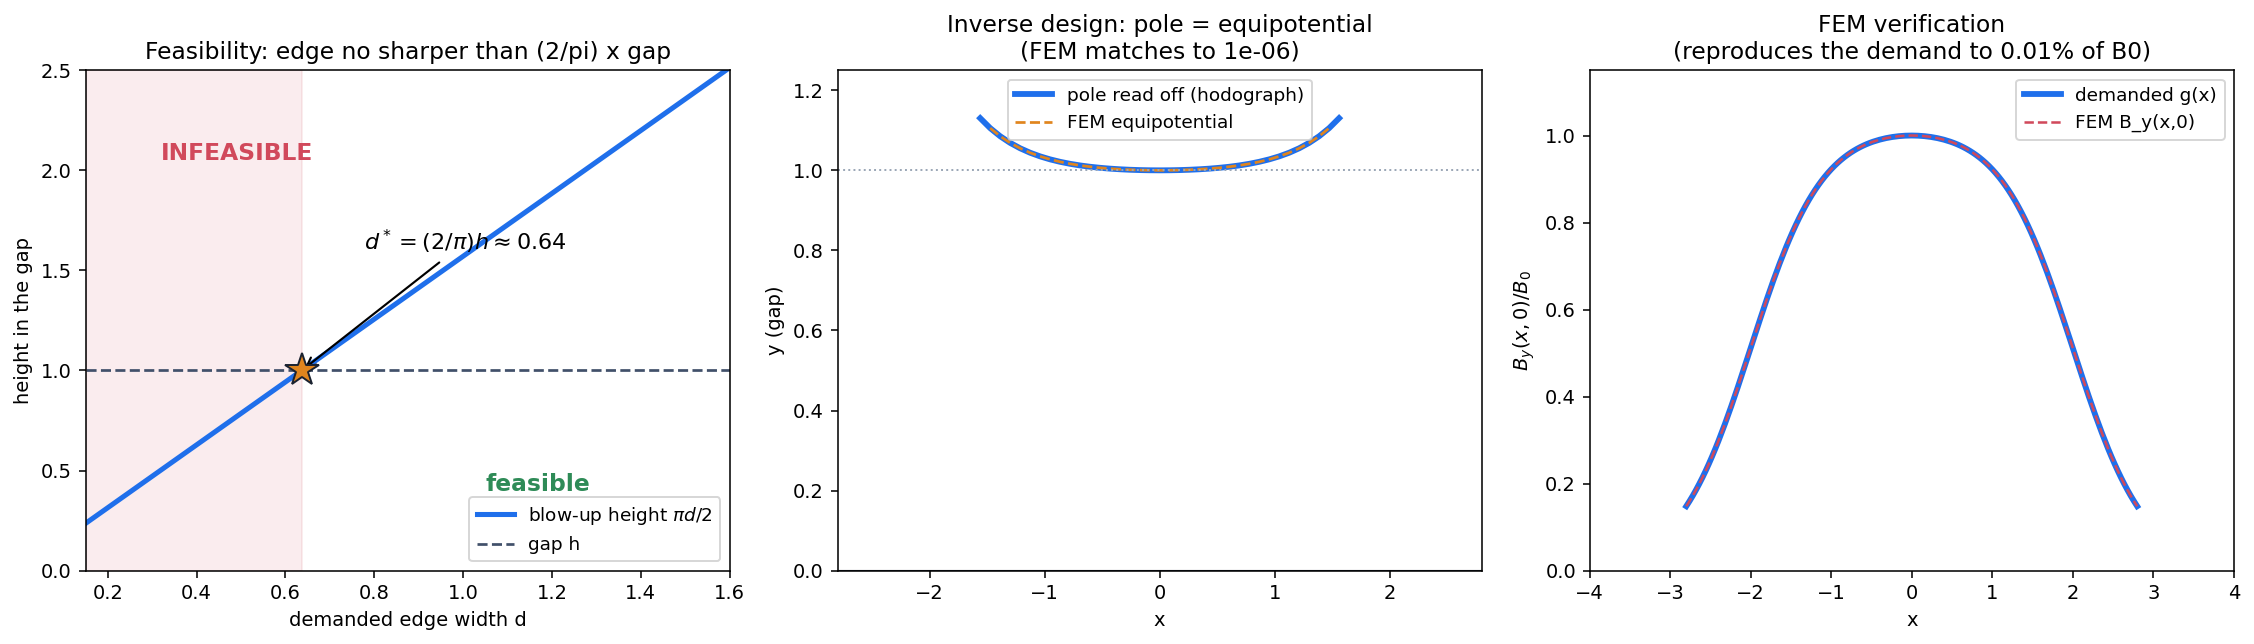

In [4]:
from IPython.display import Image, display
png = hf.figure(res, "hodograph_feasibility_2d.png")
display(Image(filename=png))

## 3. What the hodograph actually buys: the free boundary becomes a fixed edge

The Sugahara-lab hodograph is a **partial** (von-Mises-type) transform: *keep one coordinate,
transform one potential*. Here keep $x$ and replace $y$ by the scalar-potential coordinate
$s=-\phi$ (monotone in $y$ because $B_y=-\phi_y>0$ across the gap; $s=0$ on the mid-plane,
$s=s_0$ at the pole). The **unknown iron-pole shape** — a *free boundary* in physical space —
becomes the **fixed top edge** $\{s=s_0\}$ of the rectangle $[-x_r,x_r]\times[0,s_0]$. The
physical map $y(x,s)$ solves the (quasi-linear) von-Mises PDE
$$y_s^2\,y_{xx}-2\,y_x y_s\,y_{xs}+(1+y_x^2)\,y_{ss}=0,$$
with Jacobian $y_s>0$ everywhere (single-valued, no fold). We check both on the closed-form map,
at two grid resolutions: the PDE residual $\to 0$ under refinement (confirming the PDE *and* that
the map solves it), while the pole (top edge) reproduces the read-off equipotential.

In [5]:
vm_c = hf.vonmises_chart(nX=81, nS=61)
vm = hf.vonmises_chart(nX=161, nS=121)
print(f"coarse 81x61  : von Mises PDE relative residual = {vm_c['pde_resid']:.2e}")
print(f"fine 161x121  : von Mises PDE relative residual = {vm['pde_resid']:.2e}"
      f"  (~4x smaller -> O(h^2): the PDE is satisfied)")
print(f"Jacobian y_s>0 everywhere (single-valued map) : {vm['single_valued']} (min y_s = {vm['jac_min']:.3f})")
print(f"pole = fixed top edge s=s0 vs read-off pole   : max |dy| = {vm['pole_match']:.1e}"
      f"  (s0 = {vm['s0']:.3f})")

coarse 81x61  : von Mises PDE relative residual = 2.62e-03
fine 161x121  : von Mises PDE relative residual = 7.19e-04  (~4x smaller -> O(h^2): the PDE is satisfied)
Jacobian y_s>0 everywhere (single-valued map) : True (min y_s = 0.782)
pole = fixed top edge s=s0 vs read-off pole   : max |dy| = 2.5e-08  (s0 = 1.015)


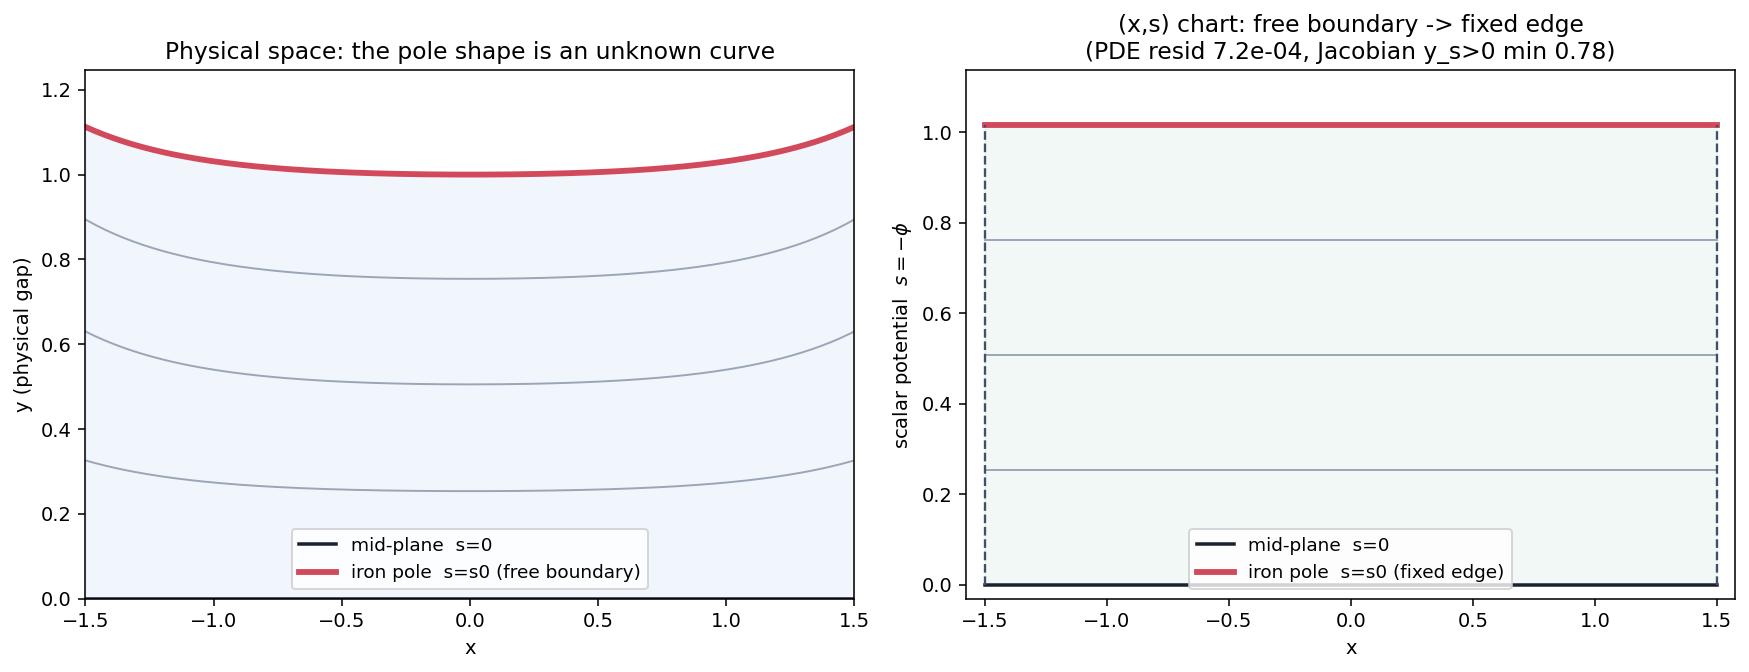

In [6]:
png2 = hf.figure_vonmises(vm, "hodograph_feasibility_2d_vonmises.png")
display(Image(filename=png2))

## 4. Honest scope, and the bridge to saturation

* The feasibility bound (§1) is **harmonic analysis**, not the hodograph; the $2/\pi$ is
  $\tanh$-specific and only the gap scaling is universal.
* The transparency (§3) **is** the hodograph: designing in field space turns the unknown pole
  shape into a fixed-domain elliptic problem for the coordinate map $y(x,s)$.
* **Saturation stays elliptic.** For ordinary passive iron $\mu$ falls but $|B|=\mu|H|$ still
  *rises* ($d(\mu q)/dq>0$), so the field-space PDE never changes type — there is **no limit line
  / shock** here (unlike transonic gas dynamics). In the partial $(x,s)$ chart, saturation enters
  as a **coefficient** $\mu(q)$ on the *same fixed rectangle*: the design stays a fixed-domain
  solve, now with a variable coefficient. That is the genuine, honest payoff — and the nonlinear
  $(x,s)$ / Chaplygin design is the natural next build.

In [7]:
def _ver(m):
    try:
        return __import__(m).__version__
    except Exception:
        return None

vm_json = {k: v for k, v in vm.items() if not k.startswith("_")}
vm_json["pde_resid_coarse"] = vm_c["pde_resid"]

payload = {
    "generated_at_utc": datetime.datetime.now(datetime.timezone.utc).isoformat(),
    "radia_version": _ver("radia"), "ngsolve_version": _ver("ngsolve"),
    "python_version": platform.python_version(), "platform": platform.platform(),
    "x0": hf.X0, "gap_h": hf.H, "edge_d": hf.D, "d_star": float(hf.d_star()),
    "feasibility_table": hf.feasibility_table([1.4, 1.0, 0.8, hf.d_star(), 0.5, 0.35]),
    "fem_verify": {k: v for k, v in res.items() if not k.startswith("_")},
    "vonmises_chart": vm_json,
}
with open("hodograph_feasibility_2d.json", "w") as fh:
    json.dump(payload, fh, indent=2)
print("saved hodograph_feasibility_2d.json  (d*=%.4f, By rel err %.3f%%, pole %.1e; "
      "vonMises PDE resid %.2e, y_s>0 %s)"
      % (payload["d_star"], res["By_rel_err"]*100, res["pole_match_err"],
         vm["pde_resid"], vm["single_valued"]))

saved hodograph_feasibility_2d.json  (d*=0.6366, By rel err 0.010%, pole 1.4e-06; vonMises PDE resid 7.19e-04, y_s>0 True)
